In [153]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
import glob

In [166]:
orig_path = '/Users/chrisiyer/_Current/lab/code/hybrid_rl/fmri_analysis/data/hybrid_data.csv'
orig = pd.read_csv(orig_path).groupby(['Sub','ObjPP']).mean('OldObjC').reset_index()
orig = orig.rename(columns={'ObjPP':'OldValue', 'OldObjC': 'OldChosen'})[['Sub','OldValue','OldChosen']]
orig['stim_type'] = 'nan'

In [184]:
dist_dir = '/Users/chrisiyer/_Current/lab/code/mem-rl/mem-ep-inc/data/distinctiveness'
dist = pd.concat([pd.read_csv(f) for f in glob.glob(dist_dir + '/*.csv')])
dist = dist[~pd.isna(dist.did_choose_old)].groupby(['subject_id','old_reward','stim_type']).mean('did_choose_old').reset_index()
dist = dist.rename(columns={'old_reward':'OldValue', 'did_choose_old': 'OldChosen'})
dist = dist[['subject_id','OldValue','OldChosen', 'stim_type']]

In [216]:
def plot(group_df, title=''):

    plt.figure(figsize=(3,3), dpi=200)
    plt.suptitle(title)
    plt.xlabel('Old Object Value', fontsize=12)
    plt.ylabel('P(Choose Old Object)', fontsize=12)
    plt.ylim(0.2, 0.8)
    plt.yticks([0.2, 0.4, 0.6, 0.8])
    plt.xlim(-0.05,1.05)
    plt.xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
    plt.hlines(y=0.5, xmin=-0.05, xmax=1.05, color='gray', linestyle='--')
    
    # plt.plot(group_df['mean'], linewidth=3, color='#9b59b6')
    if len(group_df.stim_type.unique())>1:
        plt.ylim(0, 1)
        plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        sns.pointplot(data=group_df, x='OldValue', y='OldChosen', hue='stim_type', errorbar='se', markersize=8,
                    native_scale=True, linewidth=2, hue_order=['low','high'], palette=['tab:orange','tab:blue'],dodge=True)
    else:     
        
        sns.pointplot(data=group_df, x='OldValue', y='OldChosen', color='#4C72B0', errorbar='se', markersize=8,
                    native_scale=True, linewidth=2, legend=False)

    plt.legend(loc='lower right', title='Object Distinctiveness')
    plt.show() 

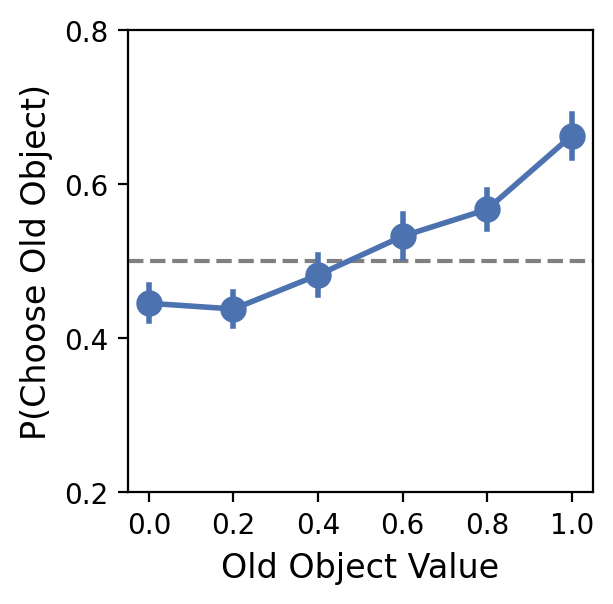

In [151]:
plot(orig)

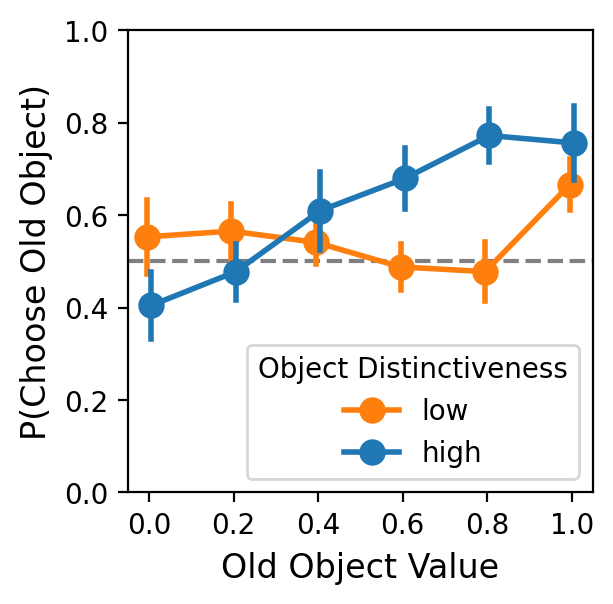

In [217]:
plot(dist)